In [2]:
!pip install contextily geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 110.8 MB/s eta 0:00:00


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

import contextily as ctx
import geopandas as gpd
from shapely.geometry import box


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv("/content/Received_Traffic_Incident_Calls_20250405.csv")
zone_counts = data['POLICE DISTRICT'].value_counts().reset_index()
zone_counts.columns = ['POLICE DISTRICT', 'Incident Count']

total_incidents = zone_counts['Incident Count'].sum()
zone_counts['Percentage (%)'] = (zone_counts['Incident Count'] / total_incidents * 100).round(2)

print(zone_counts)


  POLICE DISTRICT  Incident Count  Percentage (%)
0      District D           55738           25.74
1      District E           48324           22.32
2      District B           43188           19.95
3      District C           32188           14.87
4      District A           28897           13.35
5         UNKNOWN            8184            3.78


In [ ]:
known_zones = zone_counts[zone_counts['POLICE DISTRICT'] != 'UNKNOWN'].copy()
total_known = known_zones['Incident Count'].sum()
known_zones['Normalized %'] = (known_zones['Incident Count'] / total_known * 100).round(2)

print(known_zones)


  POLICE DISTRICT  Incident Count  Percentage (%)  Normalized %
0      District D           55738           25.74         26.75
1      District E           48324           22.32         23.20
2      District B           43188           19.95         20.73
3      District C           32188           14.87         15.45
4      District A           28897           13.35         13.87


In [ ]:

data.columns = data.columns.str.strip().str.upper()
ambulance_keywords = ['INJURY', 'FATAL']
ambulance_data = data[data['ACCIDENT TYPE'].str.contains('|'.join(ambulance_keywords), case=False, na=False)]

tow_keywords = ['SKYWAY', 'VEHICLE DAMAGE', 'DISABLED', 'TOW']
tow_data = data[data['ACCIDENT TYPE'].str.contains('|'.join(tow_keywords), case=False, na=False)]

ambulance_counts = ambulance_data['POLICE DISTRICT'].value_counts().reset_index()
ambulance_counts.columns = ['POLICE DISTRICT', 'Ambulance Count']

tow_counts = tow_data['POLICE DISTRICT'].value_counts().reset_index()
tow_counts.columns = ['POLICE DISTRICT', 'Tow Truck Count']

merged = pd.merge(ambulance_counts, tow_counts, on='POLICE DISTRICT', how='outer').fillna(0)
merged = merged[merged['POLICE DISTRICT'].str.upper() != 'UNKNOWN'].copy()
merged['Ambulance %'] = (merged['Ambulance Count'] / merged['Ambulance Count'].sum() * 100).round(2)
merged['Tow %'] = (merged['Tow Truck Count'] / merged['Tow Truck Count'].sum() * 100).round(2)
merged_sorted = merged.sort_values(by='Ambulance %', ascending=False).reset_index(drop=True)

print(merged_sorted)


  POLICE DISTRICT  Ambulance Count  Tow Truck Count  Ambulance %  Tow %
0      District E            10468             4920        24.66  43.72
1      District D            10134             3657        23.87  32.50
2      District B             8282              207        19.51   1.84
3      District C             8224             1533        19.37  13.62
4      District A             5343              936        12.59   8.32


In [ ]:

total_police_vans = 75
total_ambulances = 40
total_tow_trucks = 25

districts = ['District D', 'District E', 'District B', 'District C', 'District A']
police_percent = [26.75, 23.20, 20.73, 15.45, 13.87]  # Normalized %
ambulance_percent = [23.87, 24.66, 19.51, 19.37, 12.59]
tow_percent = [32.50, 43.72, 1.84, 13.62, 8.32]
allocations = []

for i in range(len(districts)):
    police = round(police_percent[i] / 100 * total_police_vans)
    ambulance = round(ambulance_percent[i] / 100 * total_ambulances)
    tow = round(tow_percent[i] / 100 * total_tow_trucks)

    allocations.append({
        'District': districts[i],
        'Police Vans': police,
        'Ambulances': ambulance,
        'Tow Trucks': tow
    })

alloc_df = pd.DataFrame(allocations)

alloc_df['Police Vans'] += (total_police_vans - alloc_df['Police Vans'].sum())
alloc_df['Ambulances'] += (total_ambulances - alloc_df['Ambulances'].sum())
alloc_df['Tow Trucks'] += (total_tow_trucks - alloc_df['Tow Trucks'].sum())

print(alloc_df)


     District  Police Vans  Ambulances  Tow Trucks
0  District D           20           9           9
1  District E           17           9          12
2  District B           16           7           1
3  District C           12           7           4
4  District A           10           4           3


In [ ]:

data = data.dropna(subset=['LOCATION', 'POLICE DISTRICT'])

data[['LONGITUDE', 'LATITUDE']] = data['LOCATION'].str.extract(r'POINT \(([-\d\.]+) ([-\d\.]+)\)').astype(float)

district_coords = data.groupby('POLICE DISTRICT')[['LATITUDE', 'LONGITUDE']].mean().reset_index()

district_coords = district_coords[district_coords['POLICE DISTRICT'].str.upper() != 'UNKNOWN']

district_coords['LATITUDE'] = district_coords['LATITUDE'].round(6)
district_coords['LONGITUDE'] = district_coords['LONGITUDE'].round(6)
print(district_coords)


  POLICE DISTRICT   LATITUDE  LONGITUDE
0      District A  42.862544 -78.830878
1      District B  42.896844 -78.873691
2      District C  42.901333 -78.830383
3      District D  42.938006 -78.874345
4      District E  42.930578 -78.825083


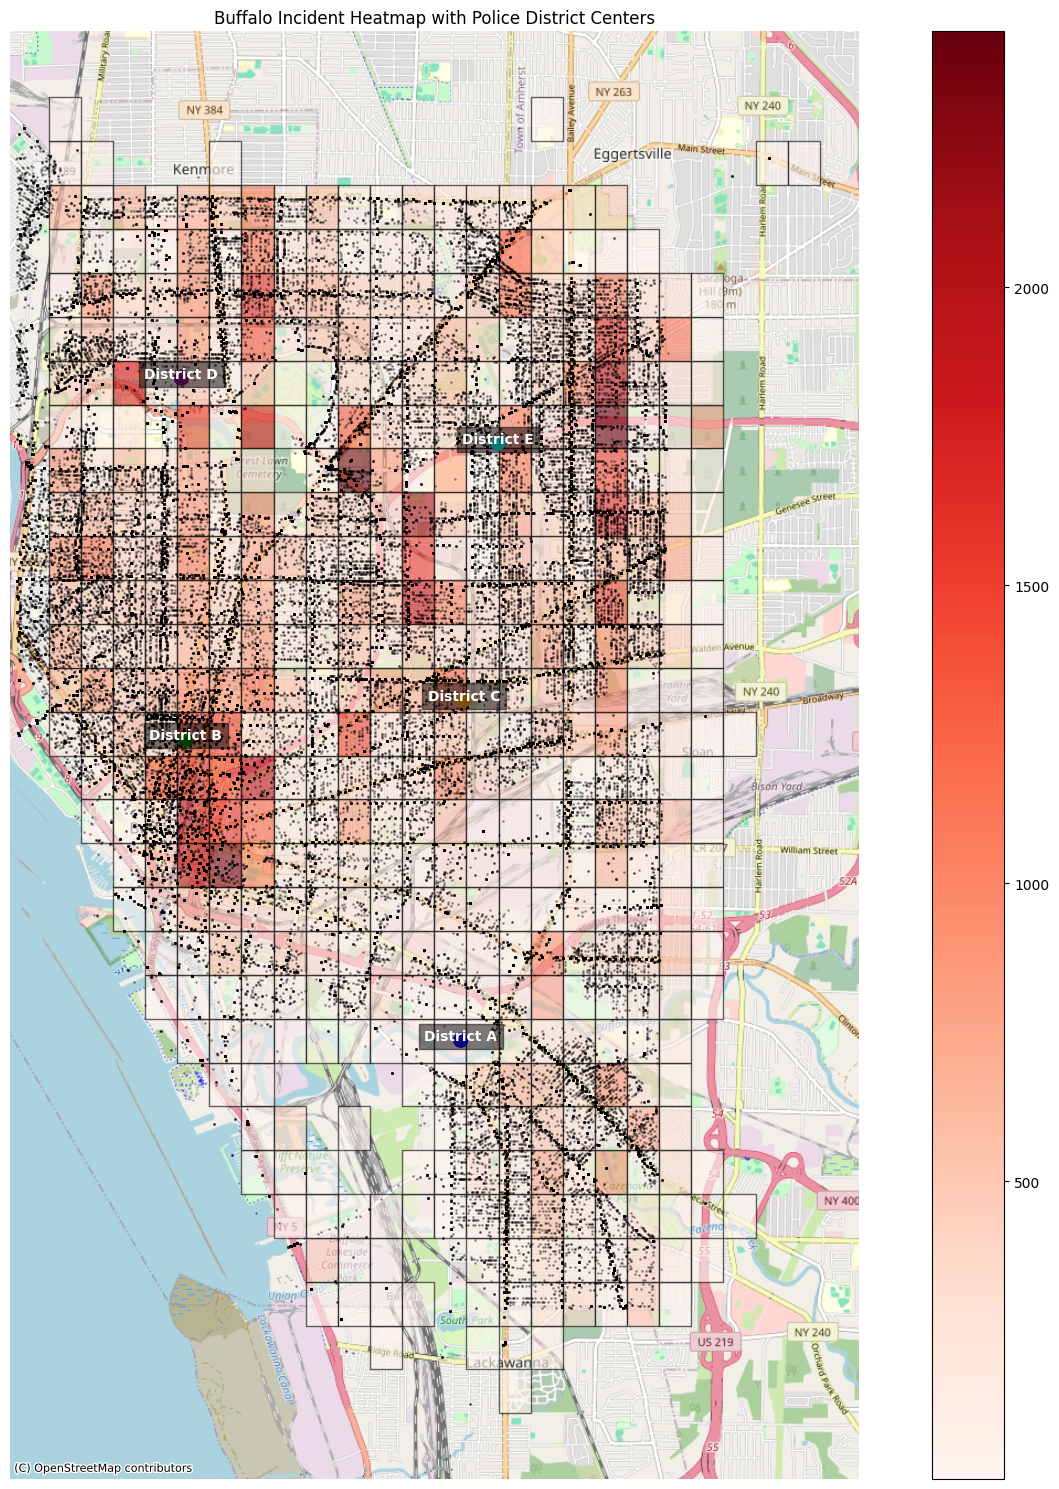

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import contextily as ctx

data.columns = data.columns.str.strip().str.upper()
data = data.dropna(subset=['LOCATION', 'POLICE DISTRICT'])

data[['LONGITUDE', 'LATITUDE']] = data['LOCATION'].str.extract(r'POINT \(([-\d\.]+) ([-\d\.]+)\)').astype(float)
buffalo_bounds = {
    'min_lat': 42.82,
    'max_lat': 42.97,
    'min_lon': -78.90,
    'max_lon': -78.78
}

data = data[
    (data['LATITUDE'] >= buffalo_bounds['min_lat']) &
    (data['LATITUDE'] <= buffalo_bounds['max_lat']) &
    (data['LONGITUDE'] >= buffalo_bounds['min_lon']) &
    (data['LONGITUDE'] <= buffalo_bounds['max_lon'])
].copy()

# Create 0.005° x 0.005° grid bins (~500m)
data['lat_bin'] = (data['LATITUDE'] * 200).astype(int)
data['lon_bin'] = (data['LONGITUDE'] * 200).astype(int)
data['zone_id'] = data['lat_bin'].astype(str) + "_" + data['lon_bin'].astype(str)

# Group incident count per grid
zone_counts = data.groupby(['lat_bin', 'lon_bin']).size().reset_index(name='incident_count')

# Convert bins to polygons
zone_counts['geometry'] = zone_counts.apply(
    lambda row: box(
        row['lon_bin'] / 200,
        row['lat_bin'] / 200,
        row['lon_bin'] / 200 + 0.005,
        row['lat_bin'] / 200 + 0.005
    ), axis=1
)

# Convert to GeoDataFrame and project to Web Mercator
gdf = gpd.GeoDataFrame(zone_counts, geometry='geometry', crs="EPSG:4326").to_crs(epsg=3857)

# Create GeoDataFrame for incident points
points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(data['LONGITUDE'], data['LATITUDE']),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# Define police district center
district_data = {
    'District': ['District A', 'District B', 'District C', 'District D', 'District E'],
    'Latitude': [42.862544, 42.896844, 42.901333, 42.938006, 42.930578],
    'Longitude': [-78.830878, -78.873691, -78.830383, -78.874345, -78.825083],
    'Color': ['blue', 'green', 'orange', 'purple', 'cyan']
}
district_df = pd.DataFrame(district_data)
district_gdf = gpd.GeoDataFrame(
    district_df,
    geometry=gpd.points_from_xy(district_df['Longitude'], district_df['Latitude']),
    crs="EPSG:4326"
).to_crs(epsg=3857)

ax = gdf.plot(column='incident_count', cmap='Reds', figsize=(15, 15), alpha=0.6, edgecolor='black', legend=True)
points.plot(ax=ax, color='black', markersize=1, alpha=0.3, label='Incidents')
district_gdf.plot(ax=ax, color=district_df['Color'], markersize=100, alpha=0.9, label='District Centers')

for x, y, label in zip(district_gdf.geometry.x, district_gdf.geometry.y, district_gdf['District']):
    ax.text(x, y, label, fontsize=10, fontweight='bold', ha='center', color='white', bbox=dict(facecolor='black', alpha=0.5))
minx, miny, maxx, maxy = gdf.total_bounds
margin_x = (maxx - minx) * 0.05
margin_y = (maxy - miny) * 0.05
ax.set_xlim(minx - margin_x, maxx + margin_x)
ax.set_ylim(miny - margin_y, maxy + margin_y)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.title("Buffalo Incident Heatmap with Police District Centers")
plt.axis('off')
plt.tight_layout()
plt.show()


In [15]:
pip install gym stable-baselines3 matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 45.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [ ]:
import folium

buffalo_center = [42.91, -78.85]
m = folium.Map(location=buffalo_center, zoom_start=12, tiles='CartoDB Positron')
ambulance_filter = data['ACCIDENT TYPE'].str.contains("injury", case=False, na=False)
tow_filter = data['ACCIDENT TYPE'].str.contains("skyway", case=False, na=False)

police_filter = (
    data['ACCIDENT TYPE'].str.contains("accident", case=False, na=False) &
    ~ambulance_filter & ~tow_filter
)
police_locs = data[police_filter][['LATITUDE', 'LONGITUDE']].dropna().values  # No [:500]

ambulance_locs = data[ambulance_filter][['LATITUDE', 'LONGITUDE']].dropna().values[:500]
tow_locs = data[tow_filter][['LATITUDE', 'LONGITUDE']].dropna().values[:500]

N = 500
police_locs = police_locs[:N]
ambulance_locs = ambulance_locs[:N]
tow_locs = tow_locs[:N]

for lat, lon in police_locs:
    folium.CircleMarker([lat, lon], radius=3, color='blue', fill=True, fill_opacity=0.6).add_to(m)

for lat, lon in ambulance_locs:
    folium.CircleMarker([lat, lon], radius=3, color='red', fill=True, fill_opacity=0.6).add_to(m)

for lat, lon in tow_locs:
    folium.CircleMarker([lat, lon], radius=3, color='green', fill=True, fill_opacity=0.6).add_to(m)

m


In [ ]:
from folium.plugins import MarkerCluster

m = folium.Map(location=[42.91, -78.85], zoom_start=12, tiles='CartoDB Positron')
police_cluster = MarkerCluster(name="Police").add_to(m)
ambulance_cluster = MarkerCluster(name="Ambulance").add_to(m)
tow_cluster = MarkerCluster(name="Tow Truck").add_to(m)

for lat, lon in police_locs:
    folium.CircleMarker([lat, lon], radius=3, color='blue', fill=True, fill_opacity=0.6).add_to(police_cluster)

for lat, lon in ambulance_locs:
    folium.CircleMarker([lat, lon], radius=3, color='red', fill=True, fill_opacity=0.6).add_to(ambulance_cluster)

for lat, lon in tow_locs:
    folium.CircleMarker([lat, lon], radius=3, color='green', fill=True, fill_opacity=0.6).add_to(tow_cluster)

folium.LayerControl().add_to(m)
m


In [ ]:
districts = {
    "District A": [42.862544, -78.830878],
    "District B": [42.896844, -78.873691],
    "District C": [42.901333, -78.830383],
    "District D": [42.938006, -78.874345],
    "District E": [42.930578, -78.825083],
}

resource_counts = {
    "District A": {"Police": 10, "Ambulance": 4, "Tow": 3},
    "District B": {"Police": 16, "Ambulance": 7, "Tow": 1},
    "District C": {"Police": 12, "Ambulance": 7, "Tow": 4},
    "District D": {"Police": 20, "Ambulance": 9, "Tow": 9},
    "District E": {"Police": 17, "Ambulance": 9, "Tow": 12},
}
import random

def jitter_location(lat, lon, factor=0.002):
    return lat + random.uniform(-factor, factor), lon + random.uniform(-factor, factor)

for district, center in districts.items():
    counts = resource_counts[district]
    lat, lon = center

    for _ in range(counts["Police"]):
        jlat, jlon = jitter_location(lat, lon)
        folium.Marker(
            location=[jlat, jlon],
            popup=f"{district} - Police Van",
            icon=folium.Icon(color="blue", icon="shield", prefix="fa")
        ).add_to(m)

    for _ in range(counts["Ambulance"]):
        jlat, jlon = jitter_location(lat, lon)
        folium.Marker(
            location=[jlat, jlon],
            popup=f"{district} - Ambulance",
            icon=folium.Icon(color="red", icon="plus-square", prefix="fa")
        ).add_to(m)

    for _ in range(counts["Tow"]):
        jlat, jlon = jitter_location(lat, lon)
        folium.Marker(
            location=[jlat, jlon],
            popup=f"{district} - Tow Truck",
            icon=folium.Icon(color="green", icon="truck", prefix="fa")
        ).add_to(m)


In [37]:
m